# Config B — Deep RL: DQN & PPO

**Environment:** ICU-Sepsis-v2 — 47-dimensional continuous observation space, Discrete(25) action space  
**Algorithms:** Deep Q-Network (DQN) · Proximal Policy Optimization (PPO)

### Why deep RL for Config B?
Config B replaces the discrete state index with a 47-dimensional physiological feature vector (SOFA score, heart rate, lactate, blood pressure, …). The state space is now continuous and effectively infinite — tabular methods are infeasible. A neural network function approximator is required to generalise across unseen states.

### Clinical failure wrappers (always active)
| Wrapper | Effect | Rate |
|---------|--------|------|
| `EpisodicNoisyObsEnv` | Gaussian noise on all observations | 15% of episodes |
| `EpisodicMissingObsEnv` | 4 lab features zeroed out | 15% of episodes |
| `AcuteEventEnv` | Sudden irreversible patient death | 1% per step (~9% per episode) |

**Random baseline to beat:** 65.6% survival · mean return 0.5624

## 0. Setup

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from envs.wrappers import make_clinical_env
from agents.config_b.dqn import DQNConfig, train_dqn, load_dqn, get_policy as dqn_get_policy
from agents.config_b.ppo import PPOConfig, train_ppo, load_ppo, get_policy as ppo_get_policy
from utils.evaluation import eval_agent, print_results

sns.set_theme(style='whitegrid', palette='tab10')
SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Setup complete.


## 1. Random Baseline
Lower bound — any trained agent must exceed this.

In [3]:
_env = make_clinical_env()
n_actions = _env.action_space.n
_env.close()
random_policy  = lambda obs: np.random.randint(n_actions)
random_results = eval_agent(random_policy, make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('Random Baseline (Config B)', random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config B) ===
  Mean return  : 0.5745 ± 0.4720
  Survival rate: 67.2%
  Mean ep len  : 9.8


---
## 2. Hyperparameter Search

Finding good hyperparameters by hand is unreliable. We use **random search** (Bergstra & Bengio, 2012): sample N random configurations from a predefined search space, train each for a reduced number of timesteps, evaluate quickly, and pick the best.

**Why random search over grid search?**  
Grid search scales exponentially — 3 values × 3 hyperparameters = 27 combinations per algorithm. Random search samples the same space more efficiently and is proven to find better solutions in fewer trials when only a subset of hyperparameters actually matter.

**Setup:** 8 random trials per algorithm · 100k timesteps each · 200 eval episodes per trial.  
The best configs are then used for full training (500k timesteps) in the sections below.

In [4]:
import itertools
from utils.evaluation import eval_agent

rng = np.random.default_rng(SEED)

N_TRIALS        = 8      # random trials per algorithm
SEARCH_STEPS    = 100_000  # timesteps per trial (fast)
SEARCH_EVAL_EPS = 200      # eval episodes per trial (fast)

# ── DQN search space ─────────────────────────────────────────────────────────
dqn_space = {
    'learning_rate':          [1e-4, 3e-4, 1e-3],
    'exploration_fraction':   [0.15, 0.25, 0.35],
    'target_update_interval': [250, 500, 1000],
    'batch_size':             [32, 64, 128],
}

# ── PPO search space ──────────────────────────────────────────────────────────
ppo_space = {
    'learning_rate': [1e-4, 3e-4, 1e-3],
    'n_steps':       [512, 1024, 2048],
    'ent_coef':      [0.0, 0.005, 0.01, 0.05],
    'batch_size':    [32, 64, 128],
}

def sample_config(space: dict, rng) -> dict:
    return {k: rng.choice(v).item() for k, v in space.items()}

print(f"Running {N_TRIALS} random trials per algorithm ({SEARCH_STEPS:,} steps each)...")
print("This will take a few minutes.\n")

Running 8 random trials per algorithm (100,000 steps each)...
This will take a few minutes.



In [5]:
# ── DQN random search (cached) ────────────────────────────────────────────────
import os, json
from agents.config_b.dqn import load_dqn

DQN_SEARCH_CSV = 'results/config_b/search/dqn_search_results.csv'
os.makedirs('results/config_b/search', exist_ok=True)

if os.path.exists(DQN_SEARCH_CSV):
    print("CSV found — loading cached DQN search results (no training needed).")
    dqn_search_df = pd.read_csv(DQN_SEARCH_CSV)
else:
    dqn_search_results = []
    for trial in range(N_TRIALS):
        zip_path  = f'results/config_b/search/dqn_trial_{trial}.zip'
        cfg_path  = f'results/config_b/search/dqn_trial_{trial}_config.json'

        if os.path.exists(zip_path) and os.path.exists(cfg_path):
            # Load saved config — don't sample (would give wrong hyperparams)
            with open(cfg_path) as f:
                sampled = json.load(f)
            model = load_dqn(zip_path.replace('.zip', ''))
            print(f"  Trial {trial+1}/{N_TRIALS} | zip+config found — skipping training")
        else:
            sampled = sample_config(dqn_space, rng)
            cfg = DQNConfig(total_timesteps=SEARCH_STEPS, seed=SEED, **sampled)
            model, _ = train_dqn(make_clinical_env, cfg,
                                 save_path=f'results/config_b/search/dqn_trial_{trial}')
            with open(cfg_path, 'w') as f:
                json.dump(sampled, f)
            print(f"  Trial {trial+1}/{N_TRIALS} | trained & saved")

        res = eval_agent(dqn_get_policy(model), make_clinical_env,
                         n_eval_episodes=SEARCH_EVAL_EPS, seed=SEED)
        dqn_search_results.append({'trial': trial, **sampled,
                                    'survival_rate': res['survival_rate'],
                                    'mean_return':   res['mean_return']})
        print(f"            survival={res['survival_rate']:.1%} | config={sampled}")

    dqn_search_df = pd.DataFrame(dqn_search_results).sort_values('survival_rate', ascending=False)
    dqn_search_df.to_csv(DQN_SEARCH_CSV, index=False)
    print(f"\nResults saved to {DQN_SEARCH_CSV}")

print(f"\nDQN best survival rate: {dqn_search_df.iloc[0]['survival_rate']:.1%}")
print(dqn_search_df.to_string(index=False))

CSV found — loading cached DQN search results (no training needed).

DQN best survival rate: 73.5%
 trial  learning_rate  exploration_fraction  target_update_interval  batch_size  survival_rate  mean_return
     0         0.0001                  0.35                     500          64          0.735     0.673412
     1         0.0003                  0.35                     250         128          0.730     0.651225
     2         0.0001                  0.15                     500         128          0.710     0.643800
     4         0.0003                  0.15                    1000          64          0.710     0.629112
     3         0.0010                  0.35                    1000         128          0.695     0.641325
     6         0.0010                  0.25                     500         128          0.690     0.622888
     7         0.0003                  0.25                     500          32          0.685     0.594063
     5         0.0003                

In [6]:
# ── PPO random search (cached) ────────────────────────────────────────────────
from agents.config_b.ppo import load_ppo

PPO_SEARCH_CSV = 'results/config_b/search/ppo_search_results.csv'

if os.path.exists(PPO_SEARCH_CSV):
    print("CSV found — loading cached PPO search results (no training needed).")
    ppo_search_df = pd.read_csv(PPO_SEARCH_CSV)
else:
    ppo_search_results = []
    for trial in range(N_TRIALS):
        zip_path = f'results/config_b/search/ppo_trial_{trial}.zip'
        cfg_path = f'results/config_b/search/ppo_trial_{trial}_config.json'

        if os.path.exists(zip_path) and os.path.exists(cfg_path):
            with open(cfg_path) as f:
                sampled = json.load(f)
            model = load_ppo(zip_path.replace('.zip', ''))
            print(f"  Trial {trial+1}/{N_TRIALS} | zip+config found — skipping training")
        else:
            sampled = sample_config(ppo_space, rng)
            cfg = PPOConfig(total_timesteps=SEARCH_STEPS, seed=SEED, **sampled)
            model, _ = train_ppo(make_clinical_env, cfg,
                                 save_path=f'results/config_b/search/ppo_trial_{trial}')
            with open(cfg_path, 'w') as f:
                json.dump(sampled, f)
            print(f"  Trial {trial+1}/{N_TRIALS} | trained & saved")

        res = eval_agent(ppo_get_policy(model), make_clinical_env,
                         n_eval_episodes=SEARCH_EVAL_EPS, seed=SEED)
        ppo_search_results.append({'trial': trial, **sampled,
                                    'survival_rate': res['survival_rate'],
                                    'mean_return':   res['mean_return']})
        print(f"            survival={res['survival_rate']:.1%} | config={sampled}")

    ppo_search_df = pd.DataFrame(ppo_search_results).sort_values('survival_rate', ascending=False)
    ppo_search_df.to_csv(PPO_SEARCH_CSV, index=False)
    print(f"\nResults saved to {PPO_SEARCH_CSV}")

print(f"\nPPO best survival rate: {ppo_search_df.iloc[0]['survival_rate']:.1%}")
print(ppo_search_df.to_string(index=False))

CSV found — loading cached PPO search results (no training needed).

PPO best survival rate: 77.0%
 trial  learning_rate  n_steps  ent_coef  batch_size  survival_rate  mean_return
     6         0.0003      512     0.010         128          0.770     0.738750
     3         0.0001     2048     0.005         128          0.765     0.732487
     4         0.0010     2048     0.050          32          0.760     0.684362
     5         0.0003     1024     0.005          32          0.730     0.677675
     0         0.0001     1024     0.050          32          0.720     0.664750
     7         0.0010     2048     0.005         128          0.700     0.620462
     2         0.0001     2048     0.010          64          0.695     0.644725
     1         0.0010     2048     0.005          64          0.680     0.613862


Best DQN config: {'learning_rate': 0.0001, 'exploration_fraction': 0.35, 'target_update_interval': 500.0, 'batch_size': 64.0}
Best PPO config: {'learning_rate': 0.0003, 'n_steps': 512.0, 'ent_coef': 0.01, 'batch_size': 128.0}


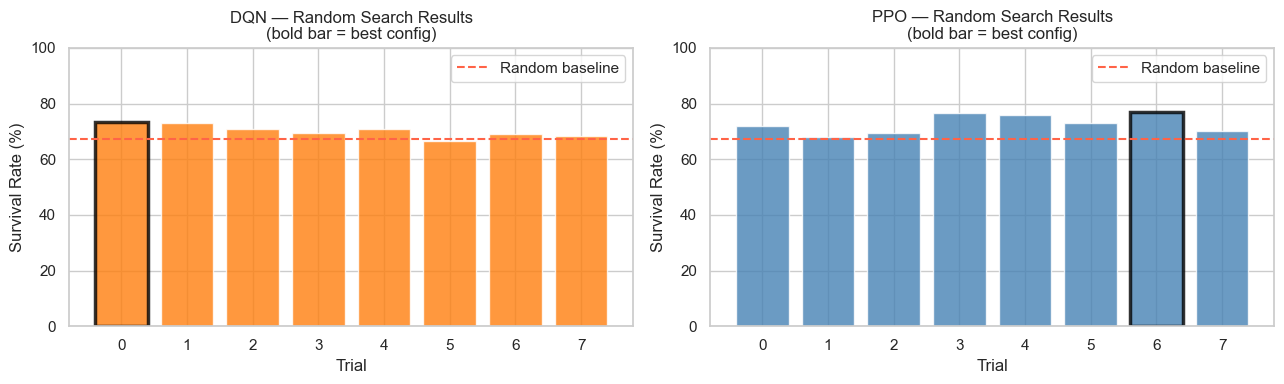

In [7]:
# ── Extract best configs and visualise search results ─────────────────────────
import os

DQN_SEARCH_CSV = 'results/config_b/search/dqn_search_results.csv'
PPO_SEARCH_CSV = 'results/config_b/search/ppo_search_results.csv'

# Load from CSV if not already in memory (e.g. kernel restart)
if 'dqn_search_df' not in locals():
    if os.path.exists(DQN_SEARCH_CSV):
        dqn_search_df = pd.read_csv(DQN_SEARCH_CSV)
        print(f"Loaded DQN search results from {DQN_SEARCH_CSV}")
    else:
        raise FileNotFoundError("DQN search results not found. Run the search cells first.")

if 'ppo_search_df' not in locals():
    if os.path.exists(PPO_SEARCH_CSV):
        ppo_search_df = pd.read_csv(PPO_SEARCH_CSV)
        print(f"Loaded PPO search results from {PPO_SEARCH_CSV}")
    else:
        raise FileNotFoundError("PPO search results not found. Run the search cells first.")

# Ensure dqn_space / ppo_space are defined (needed for column selection)
if 'dqn_space' not in locals():
    dqn_space = {'learning_rate': None, 'exploration_fraction': None,
                 'target_update_interval': None, 'batch_size': None}
if 'ppo_space' not in locals():
    ppo_space = {'learning_rate': None, 'n_steps': None,
                 'ent_coef': None, 'batch_size': None}

best_dqn_params = dqn_search_df.sort_values('survival_rate', ascending=False).iloc[0][list(dqn_space.keys())].to_dict()
best_ppo_params = ppo_search_df.sort_values('survival_rate', ascending=False).iloc[0][list(ppo_space.keys())].to_dict()

print("Best DQN config:", best_dqn_params)
print("Best PPO config:", best_ppo_params)

# Visualise: survival rate per trial for both algorithms
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, name, color in [
    (axes[0], dqn_search_df.sort_values('trial'), 'DQN', 'tab:orange'),
    (axes[1], ppo_search_df.sort_values('trial'), 'PPO', 'steelblue'),
]:
    bars = ax.bar(df['trial'], df['survival_rate'] * 100, color=color, alpha=0.8)
    best_idx = df['survival_rate'].idxmax()
    bars[df.index.get_loc(best_idx)].set_edgecolor('black')
    bars[df.index.get_loc(best_idx)].set_linewidth(2.5)
    ax.axhline(random_results['survival_rate'] * 100, color='tomato',
               linestyle='--', linewidth=1.5, label='Random baseline')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Survival Rate (%)')
    ax.set_title(f'{name} — Random Search Results\n(bold bar = best config)')
    ax.set_xticks(df['trial'])
    ax.set_ylim(0, 100)
    ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_random_search.png', dpi=150)
plt.show()

---
## 2.2 Grid Search

Random search explored the space randomly. We now run a **systematic grid search** over an expanded range to guarantee we find the best config within each grid.

**Why grid search after random search?**
Random search is unbiased but can miss specific sweet spots. Grid search is exhaustive — every combination is tried — so we can be certain no good configuration was skipped. The heatmaps also reveal the *shape* of the loss surface: which parameters matter, which don't, and how they interact.

**Expanded ranges (based on random search findings):**
- DQN: `learning_rate` extended down to 5e-5; `exploration_fraction` extended up to 0.45; `target_update_interval` fixed at 500 (low sensitivity observed)
- PPO: `ent_coef=0.0` added (does no entropy bonus hurt?); `batch_size` fixed at 128 (best from random search)

**32 DQN trials + 36 PPO trials = 68 total** · 100k steps each · ~2 hours total  
All trials are cached to `results/config_b/grid/` — safe to interrupt and resume.


In [8]:
import itertools, os, torch

N_JOBS        = 8        # parallel worker processes — change to 4 if laptop struggles
GRID_STEPS    = 100_000  # same training budget as random search (fair comparison)
GRID_EVAL_EPS = 200      # same eval budget

# ── DQN grid: 3×3×3×2×3×3 = 486 combinations ────────────────────────────────
dqn_grid = {
    'learning_rate':         [5e-5, 1e-4, 3e-4],
    'exploration_fraction':  [0.25, 0.35, 0.45],
    'net_arch':              [[64, 64], [128, 128], [256, 128]],
    'activation_fn':         ['ReLU', 'Tanh'],
    'buffer_size':           [25_000, 50_000, 100_000],
    'exploration_final_eps': [0.01, 0.05, 0.10],
}
DQN_GRID_FIXED = {'batch_size': 64, 'target_update_interval': 500}

# ── PPO grid: 2×3×2×3×2×3×3 = 648 combinations ──────────────────────────────
ppo_grid = {
    'learning_rate': [1e-4, 3e-4],
    'n_steps':       [512, 1024, 2048],
    'ent_coef':      [0.005, 0.01],
    'net_arch':      [[64, 64], [128, 128], [256, 128]],
    'activation_fn': ['ReLU', 'Tanh'],
    'n_epochs':      [5, 10, 20],
    'clip_range':    [0.1, 0.2, 0.3],
}
PPO_GRID_FIXED = {'batch_size': 128}

dqn_combos = list(itertools.product(*dqn_grid.values()))
ppo_combos = list(itertools.product(*ppo_grid.values()))

est_min = (len(dqn_combos) + len(ppo_combos)) * 2 / N_JOBS
print(f"DQN grid : {len(dqn_combos)} combinations")
print(f"PPO grid : {len(ppo_combos)} combinations")
print(f"Total    : {len(dqn_combos) + len(ppo_combos)} trials × {GRID_STEPS:,} steps")
print(f"Workers  : {N_JOBS}  →  estimated runtime ~{est_min:.0f} min")
print("\nAll trials cached to results/config_b/grid_v2/ — safe to interrupt and resume.")

DQN grid : 486 combinations
PPO grid : 648 combinations
Total    : 1134 trials × 100,000 steps
Workers  : 8  →  estimated runtime ~284 min

All trials cached to results/config_b/grid_v2/ — safe to interrupt and resume.


In [9]:
from joblib import Parallel, delayed
from utils.search import run_dqn_trial

DQN_GRID_CSV = 'results/config_b/grid_v2/dqn_grid_results.csv'
DQN_GRID_DIR = 'results/config_b/grid_v2'
os.makedirs(DQN_GRID_DIR, exist_ok=True)

if os.path.exists(DQN_GRID_CSV):
    print("CSV found — loading cached DQN grid results (no training needed).")
    dqn_grid_df = pd.read_csv(DQN_GRID_CSV)
else:
    dqn_grid_keys = list(dqn_grid.keys())

    # Build flat param dicts (activation_fn as string — picklable)
    trial_params = []
    for combo in dqn_combos:
        p = dict(zip(dqn_grid_keys, combo))
        p['net_arch'] = list(p['net_arch'])   # ensure plain list, not tuple
        p.update(DQN_GRID_FIXED)
        trial_params.append(p)

    print(f"Launching {len(trial_params)} DQN trials across {N_JOBS} workers...")
    print("Progress lines appear as workers finish (out of order is normal).\n")

    raw = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(run_dqn_trial)(
            i, params, DQN_GRID_DIR, GRID_STEPS, GRID_EVAL_EPS, SEED, project_root
        )
        for i, params in enumerate(trial_params)
    )

    # Filter out any failed trials (run_dqn_trial returns None on error)
    results = [r for r in raw if r is not None]
    failed  = len(raw) - len(results)
    if failed:
        print(f"\nWarning: {failed} trial(s) failed — excluded from results.")

    dqn_grid_df = pd.DataFrame(results).sort_values('survival_rate', ascending=False)
    dqn_grid_df.to_csv(DQN_GRID_CSV, index=False)
    print(f"\nSaved {len(results)} results to {DQN_GRID_CSV}")

print(f"\nDQN grid best survival: {dqn_grid_df.iloc[0]['survival_rate']:.1%}")
print(dqn_grid_df.head(5).to_string(index=False))

CSV found — loading cached DQN grid results (no training needed).

DQN grid best survival: 78.0%
 trial  learning_rate  exploration_fraction   net_arch activation_fn  buffer_size  exploration_final_eps  batch_size  target_update_interval  survival_rate  mean_return
   164        0.00010                  0.25   [64, 64]          ReLU        25000                   0.10          64                     500           0.78     0.698150
    35        0.00005                  0.25 [128, 128]          Tanh       100000                   0.10          64                     500           0.77     0.702150
   187        0.00010                  0.25 [128, 128]          ReLU       100000                   0.05          64                     500           0.77     0.694775
   178        0.00010                  0.25   [64, 64]          Tanh       100000                   0.05          64                     500           0.77     0.700450
    75        0.00005                  0.35 [128, 128]    

In [10]:
from utils.search import run_ppo_trial

PPO_GRID_CSV = 'results/config_b/grid_v2/ppo_grid_results.csv'
PPO_GRID_DIR = 'results/config_b/grid_v2'
os.makedirs(PPO_GRID_DIR, exist_ok=True)

if os.path.exists(PPO_GRID_CSV):
    print("CSV found — loading cached PPO grid results (no training needed).")
    ppo_grid_df = pd.read_csv(PPO_GRID_CSV)
else:
    ppo_grid_keys = list(ppo_grid.keys())

    trial_params = []
    for combo in ppo_combos:
        p = dict(zip(ppo_grid_keys, combo))
        p['net_arch'] = list(p['net_arch'])
        p.update(PPO_GRID_FIXED)
        trial_params.append(p)

    print(f"Launching {len(trial_params)} PPO trials across {N_JOBS} workers...")
    print("Progress lines appear as workers finish (out of order is normal).\n")

    raw = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
        delayed(run_ppo_trial)(
            i, params, PPO_GRID_DIR, GRID_STEPS, GRID_EVAL_EPS, SEED, project_root
        )
        for i, params in enumerate(trial_params)
    )

    results = [r for r in raw if r is not None]
    failed  = len(raw) - len(results)
    if failed:
        print(f"\nWarning: {failed} trial(s) failed — excluded from results.")

    ppo_grid_df = pd.DataFrame(results).sort_values('survival_rate', ascending=False)
    ppo_grid_df.to_csv(PPO_GRID_CSV, index=False)
    print(f"\nSaved {len(results)} results to {PPO_GRID_CSV}")

print(f"\nPPO grid best survival: {ppo_grid_df.iloc[0]['survival_rate']:.1%}")
print(ppo_grid_df.head(5).to_string(index=False))

CSV found — loading cached PPO grid results (no training needed).

PPO grid best survival: 79.5%
 trial  learning_rate  n_steps  ent_coef   net_arch activation_fn  n_epochs  clip_range  batch_size  survival_rate  mean_return
   134         0.0001     1024     0.005 [128, 128]          ReLU        20         0.3         128          0.795     0.755062
   553         0.0003     2048     0.005   [64, 64]          Tanh        10         0.2         128          0.785     0.726838
   355         0.0003      512     0.005 [128, 128]          Tanh        10         0.2         128          0.780     0.720325
   124         0.0001     1024     0.005   [64, 64]          Tanh        20         0.2         128          0.775     0.727313
   583         0.0003     2048     0.005 [256, 128]          ReLU        20         0.2         128          0.775     0.691488


Best DQN config (all searches combined): {'learning_rate': np.float64(0.0001), 'exploration_fraction': np.float64(0.25), 'batch_size': np.int64(64), 'target_update_interval': np.int64(500), 'buffer_size': np.float64(25000.0), 'exploration_final_eps': np.float64(0.1), 'net_arch': '[64, 64]', 'activation_fn': 'ReLU'}
Best PPO config (all searches combined): {'learning_rate': np.float64(0.0001), 'n_steps': np.int64(1024), 'ent_coef': np.float64(0.005), 'batch_size': np.int64(128), 'n_epochs': np.float64(20.0), 'clip_range': np.float64(0.3), 'net_arch': '[128, 128]', 'activation_fn': 'ReLU'}


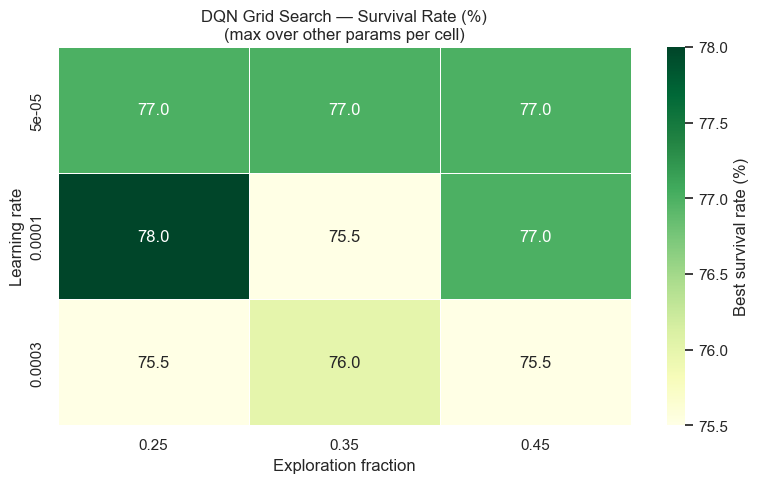

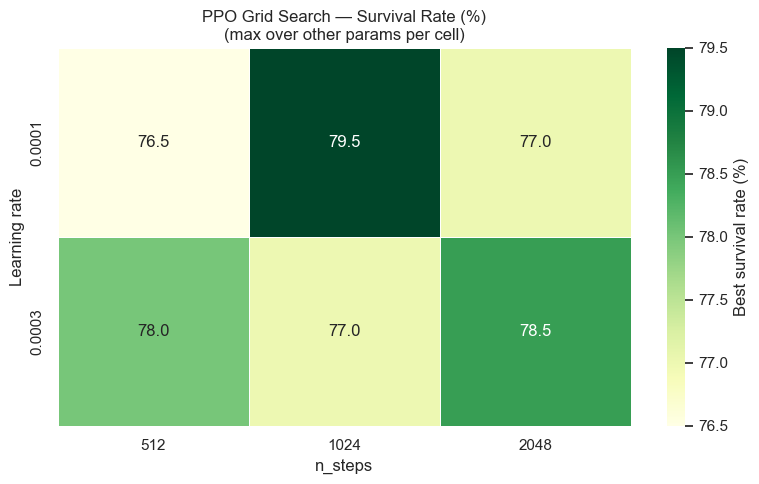

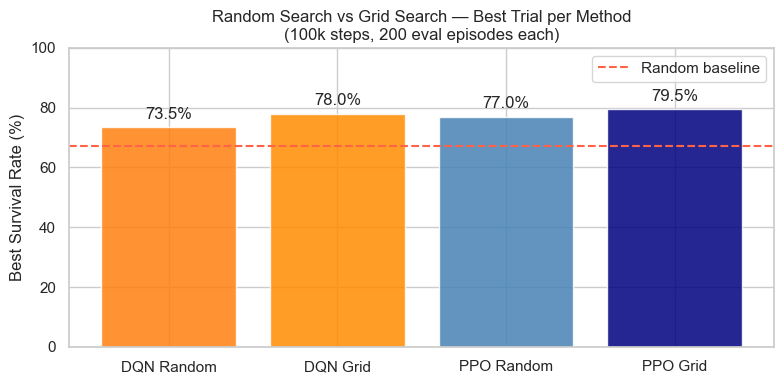

In [11]:
# ── Best config: combine random search + grid search ─────────────────────────
import os

DQN_GRID_CSV   = 'results/config_b/grid_v2/dqn_grid_results.csv'
PPO_GRID_CSV   = 'results/config_b/grid_v2/ppo_grid_results.csv'
DQN_SEARCH_CSV = 'results/config_b/search/dqn_search_results.csv'
PPO_SEARCH_CSV = 'results/config_b/search/ppo_search_results.csv'

def _best_params_from_csvs(csvs, param_keys):
    frames = [pd.read_csv(p) for p in csvs if os.path.exists(p)]
    if not frames:
        return None
    combined = pd.concat(frames, ignore_index=True)
    row = combined.sort_values('survival_rate', ascending=False).iloc[0]
    return {k: row[k] for k in param_keys if k in row}

dqn_param_keys = [
    'learning_rate', 'exploration_fraction', 'batch_size',
    'target_update_interval', 'buffer_size', 'exploration_final_eps',
    'net_arch', 'activation_fn',
]
ppo_param_keys = [
    'learning_rate', 'n_steps', 'ent_coef', 'batch_size',
    'n_epochs', 'clip_range', 'net_arch', 'activation_fn',
]

best_dqn_params = _best_params_from_csvs([DQN_SEARCH_CSV, DQN_GRID_CSV], dqn_param_keys)
best_ppo_params = _best_params_from_csvs([PPO_SEARCH_CSV, PPO_GRID_CSV], ppo_param_keys)

print("Best DQN config (all searches combined):", best_dqn_params)
print("Best PPO config (all searches combined):", best_ppo_params)

# ── Heatmap: DQN learning_rate × exploration_fraction ────────────────────────
if os.path.exists(DQN_GRID_CSV):
    gdf = pd.read_csv(DQN_GRID_CSV)
    pivot = gdf.groupby(['learning_rate', 'exploration_fraction'])['survival_rate'].max().unstack()
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Best survival rate (%)'})
    ax.set_title('DQN Grid Search — Survival Rate (%)\n(max over other params per cell)')
    ax.set_xlabel('Exploration fraction')
    ax.set_ylabel('Learning rate')
    plt.tight_layout()
    plt.savefig('plots/configB_dqn_grid_heatmap.png', dpi=150)
    plt.show()

# ── Heatmap: PPO learning_rate × n_steps ─────────────────────────────────────
if os.path.exists(PPO_GRID_CSV):
    gdf = pd.read_csv(PPO_GRID_CSV)
    pivot = gdf.groupby(['learning_rate', 'n_steps'])['survival_rate'].max().unstack()
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Best survival rate (%)'})
    ax.set_title('PPO Grid Search — Survival Rate (%)\n(max over other params per cell)')
    ax.set_xlabel('n_steps')
    ax.set_ylabel('Learning rate')
    plt.tight_layout()
    plt.savefig('plots/configB_ppo_grid_heatmap.png', dpi=150)
    plt.show()

# ── Random vs grid: best survival per method ─────────────────────────────────
comparison = {}
for label, csv in [('DQN Random', DQN_SEARCH_CSV), ('DQN Grid', DQN_GRID_CSV),
                   ('PPO Random', PPO_SEARCH_CSV), ('PPO Grid', PPO_GRID_CSV)]:
    if os.path.exists(csv):
        comparison[label] = pd.read_csv(csv)['survival_rate'].max() * 100

if len(comparison) >= 2:
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_colors = ['tab:orange', 'darkorange', 'steelblue', 'navy']
    bars = ax.bar(list(comparison.keys()), list(comparison.values()),
                  color=bar_colors[:len(comparison)], alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', padding=4)
    ax.axhline(random_results['survival_rate'] * 100, color='tomato',
               linestyle='--', linewidth=1.5, label='Random baseline')
    ax.set_ylabel('Best Survival Rate (%)')
    ax.set_title('Random Search vs Grid Search — Best Trial per Method\n(100k steps, 200 eval episodes each)')
    ax.set_ylim(0, 100)
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/configB_search_comparison.png', dpi=150)
    plt.show()

---
## 2. DQN — Deep Q-Network

### Algorithm overview
DQN approximates the action-value function $Q(s, a)$ with a neural network. It uses two key innovations over vanilla Q-learning:
- **Replay buffer** — stores past transitions and samples random mini-batches, breaking temporal correlations that destabilise gradient updates.
- **Target network** — a periodically frozen copy of the Q-network used to compute TD targets, preventing the moving-target problem.

Training follows $\epsilon$-greedy exploration: with probability $\epsilon$ a random action is taken; otherwise the greedy action $\arg\max_a Q(s,a)$ is chosen. $\epsilon$ decays from 1 to 0.05 over the first 30% of training.

### Hyperparameter justification
| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| `learning_rate` | 1e-4 | Conservative LR; DQN is sensitive to large updates |
| `buffer_size` | 50 000 | Stores ~5 000 episodes; sufficient diversity for mini-batch sampling |
| `learning_starts` | 2 000 | Fills buffer before first update — avoids degenerate early gradients |
| `batch_size` | 64 | Standard; balances variance and computational cost |
| `gamma` | 1.0 | Undiscounted — matches env convention |
| `train_freq` | 4 | Update every 4 env steps; balances sample efficiency and stability |
| `target_update_interval` | 500 | Syncs target net every 500 steps; stable relative to ~10-step episodes |
| `exploration_fraction` | 0.3 | 30% of training for $\epsilon$ decay — enough exploration across 25 actions |
| `exploration_final_eps` | 0.05 | Retains 5% random exploration throughout |
| `net_arch` | [64, 64] | Sufficient capacity for 47-dim input; avoids overfitting |

### 2.1 Training

In [ ]:
import os
import torch
from agents.config_b.dqn import load_dqn
from utils.search import ACTIVATION_MAP

DQN_MODEL_ZIP    = 'results/config_b/dqn_model.zip'
DQN_CALLBACK_NPZ = 'results/config_b/dqn_callback.npz'

if 'best_dqn_params' not in locals() or best_dqn_params is None:
    best_dqn_params = {
        'learning_rate':          1e-4,
        'exploration_fraction':   0.3,
        'target_update_interval': 500,
        'batch_size':             64,
        'buffer_size':            50_000,
        'exploration_final_eps':  0.05,
        'net_arch':               [64, 64],
        'activation_fn':          None,
    }
    print("Note: using default DQN hyperparameters (run Section 2 for tuned values)")
else:
    print("Using best DQN hyperparameters from grid/random search.")

print("\nDQN training config:")
for k, v in best_dqn_params.items():
    print(f"  {k:<26} = {v}")

# Resolve activation_fn: grid search stores it as a string ('ReLU', 'Tanh', ...)
cfg_params = dict(best_dqn_params)
act = cfg_params.get('activation_fn')
if isinstance(act, str):
    cfg_params['activation_fn'] = ACTIVATION_MAP[act]

# net_arch from CSV is stored as a string representation; convert if needed
if isinstance(cfg_params.get('net_arch'), str):
    import ast
    cfg_params['net_arch'] = ast.literal_eval(cfg_params['net_arch'])

dqn_cfg = DQNConfig(
    total_timesteps=500_000,
    seed=SEED,
    gamma=1.0,
    learning_starts=2_000,
    train_freq=4,
    **cfg_params,
)

if os.path.exists(DQN_MODEL_ZIP):
    print(f"\nCached model found — loading DQN from {DQN_MODEL_ZIP}")
    dqn_model = load_dqn('results/config_b/dqn_model')
    if os.path.exists(DQN_CALLBACK_NPZ):
        _data = np.load(DQN_CALLBACK_NPZ)
        dqn_callback = type('_CB', (), {
            'episode_returns': list(_data['episode_returns']),
            'rollout_means':   list(_data['rollout_means']),
        })()
        print(f"Loaded callback: {len(dqn_callback.episode_returns):,} episodes from cache.")
    else:
        dqn_callback = type('_CB', (), {'episode_returns': [], 'rollout_means': []})()
        print("No callback cache found — training curves will be empty.")
        print("Delete dqn_model.zip and rerun this cell to retrain and capture curves.")
else:
    print(f"\nNo cache — training DQN for {dqn_cfg.total_timesteps:,} timesteps...")
    dqn_model, dqn_callback = train_dqn(
        make_clinical_env, cfg=dqn_cfg, save_path='results/config_b/dqn_model'
    )
    np.savez(DQN_CALLBACK_NPZ,
             episode_returns=np.array(dqn_callback.episode_returns),
             rollout_means=np.array(dqn_callback.rollout_means))
    print(f"DQN training complete. Callback cached to {DQN_CALLBACK_NPZ}")

### 2.2 Training Curve

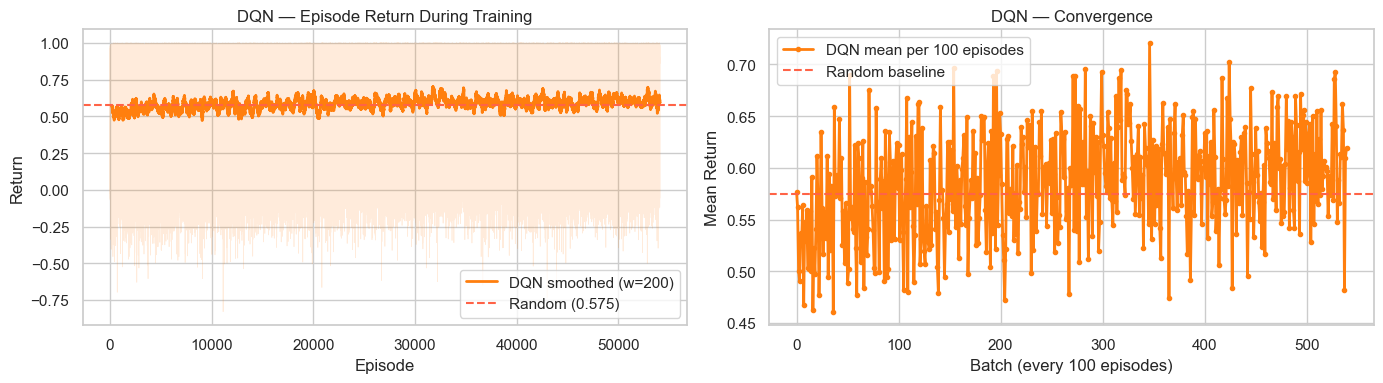

In [13]:
window = 200
dqn_returns       = np.array(dqn_callback.episode_returns)
dqn_rollout_means = np.array(dqn_callback.rollout_means)

if len(dqn_returns) < window:
    print("Not enough episodes to plot a smoothed curve — did you load from cache? "
          "Delete dqn_model.zip and rerun the training cell to retrain.")
else:
    dqn_smoothed = np.convolve(dqn_returns, np.ones(window) / window, mode='valid')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.plot(dqn_returns, alpha=0.15, color='tab:orange', linewidth=0.5)
    ax.plot(np.arange(window - 1, len(dqn_returns)), dqn_smoothed,
            color='tab:orange', linewidth=2, label=f'DQN smoothed (w={window})')
    ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
               linewidth=1.5, label=f"Random ({random_results['mean_return']:.3f})")
    ax.set_xlabel('Episode')
    ax.set_ylabel('Return')
    ax.set_title('DQN — Episode Return During Training')
    ax.legend()

    ax = axes[1]
    ax.plot(dqn_rollout_means, color='tab:orange', linewidth=2,
            marker='o', markersize=3, label='DQN mean per 100 episodes')
    ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
               linewidth=1.5, label='Random baseline')
    ax.set_xlabel('Batch (every 100 episodes)')
    ax.set_ylabel('Mean Return')
    ax.set_title('DQN — Convergence')
    ax.legend()

    plt.tight_layout()
    plt.savefig('plots/configB_dqn_training_curve.png', dpi=150)
    plt.show()


### 2.3 Evaluation

In [14]:
dqn_results = eval_agent(dqn_get_policy(dqn_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('DQN (Config B)', dqn_results)
print(f"  Improvement over random: {dqn_results['survival_rate'] - random_results['survival_rate']:+.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== DQN (Config B) ===
  Mean return  : 0.6216 ± 0.4616
  Survival rate: 69.0%
  Mean ep len  : 9.2
  Improvement over random: +1.8%


---
## 3. PPO — Proximal Policy Optimization

### Algorithm overview
PPO is an on-policy actor-critic algorithm. It directly optimises a stochastic policy $\pi_\theta(a|s)$ using gradient ascent, but constrains each update so the new policy does not deviate too far from the old one. This is achieved via a **clipped surrogate objective**:

$$L^{CLIP} = \mathbb{E}\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat{A}_t\right)\right]$$

where $r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{\text{old}}}(a_t|s_t)$ and $\varepsilon=0.2$. Advantages $\hat{A}_t$ are estimated via GAE.

**Key difference from DQN:** PPO is on-policy (learns from its own recent experience) and outputs action *probabilities*, making it a natural fit for discrete action spaces with continuous observations.

### Hyperparameter justification
| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| `learning_rate` | 3e-4 | Standard Adam LR for PPO; stable for small networks |
| `n_steps` | 1024 | ~100 full episodes per update — stable gradient estimate |
| `batch_size` | 64 | Small enough for variance reduction, large enough to be efficient |
| `n_epochs` | 10 | Multiple passes over each batch; clipping prevents over-fitting |
| `gamma` | 1.0 | Undiscounted — matches env convention |
| `gae_lambda` | 0.95 | Standard GAE smoothing; balances bias vs variance |
| `clip_range` | 0.2 | Standard PPO $\varepsilon$; prevents destructive policy updates |
| `ent_coef` | 0.01 | Small entropy bonus to maintain exploration across 25 actions |
| `net_arch` | [64, 64] | Sufficient capacity for 47-dim input without overfitting |

### 3.1 Training

In [ ]:
from agents.config_b.ppo import load_ppo
from utils.search import ACTIVATION_MAP

PPO_MODEL_ZIP    = 'results/config_b/ppo_model.zip'
PPO_CALLBACK_NPZ = 'results/config_b/ppo_callback.npz'

if 'best_ppo_params' not in locals() or best_ppo_params is None:
    best_ppo_params = {
        'learning_rate': 3e-4,
        'n_steps':       1024,
        'ent_coef':      0.01,
        'batch_size':    64,
        'n_epochs':      10,
        'clip_range':    0.2,
        'net_arch':      [64, 64],
        'activation_fn': None,
    }
    print("Note: using default PPO hyperparameters (run Section 2 for tuned values)")
else:
    print("Using best PPO hyperparameters from grid/random search.")

print("\nPPO training config:")
for k, v in best_ppo_params.items():
    print(f"  {k:<26} = {v}")

# Resolve activation_fn: grid search stores it as a string ('ReLU', 'Tanh', ...)
cfg_params = dict(best_ppo_params)
act = cfg_params.get('activation_fn')
if isinstance(act, str):
    cfg_params['activation_fn'] = ACTIVATION_MAP[act]

# net_arch from CSV is stored as a string representation; convert if needed
if isinstance(cfg_params.get('net_arch'), str):
    import ast
    cfg_params['net_arch'] = ast.literal_eval(cfg_params['net_arch'])

ppo_cfg = PPOConfig(
    total_timesteps=500_000,
    seed=SEED,
    gamma=1.0,
    gae_lambda=0.95,
    vf_coef=0.5,
    max_grad_norm=0.5,
    **cfg_params,
)

if os.path.exists(PPO_MODEL_ZIP):
    print(f"\nCached model found — loading PPO from {PPO_MODEL_ZIP}")
    ppo_model = load_ppo('results/config_b/ppo_model')
    if os.path.exists(PPO_CALLBACK_NPZ):
        _data = np.load(PPO_CALLBACK_NPZ)
        ppo_callback = type('_CB', (), {
            'episode_returns': list(_data['episode_returns']),
            'rollout_means':   list(_data['rollout_means']),
        })()
        print(f"Loaded callback: {len(ppo_callback.episode_returns):,} episodes from cache.")
    else:
        ppo_callback = type('_CB', (), {'episode_returns': [], 'rollout_means': []})()
        print("No callback cache found — training curves will be empty.")
        print("Delete ppo_model.zip and rerun this cell to retrain and capture curves.")
else:
    print(f"\nNo cache — training PPO for {ppo_cfg.total_timesteps:,} timesteps...")
    ppo_model, ppo_callback = train_ppo(
        make_clinical_env, cfg=ppo_cfg, save_path='results/config_b/ppo_model'
    )
    np.savez(PPO_CALLBACK_NPZ,
             episode_returns=np.array(ppo_callback.episode_returns),
             rollout_means=np.array(ppo_callback.rollout_means))
    print(f"PPO training complete. Callback cached to {PPO_CALLBACK_NPZ}")

### 3.2 Training Curve

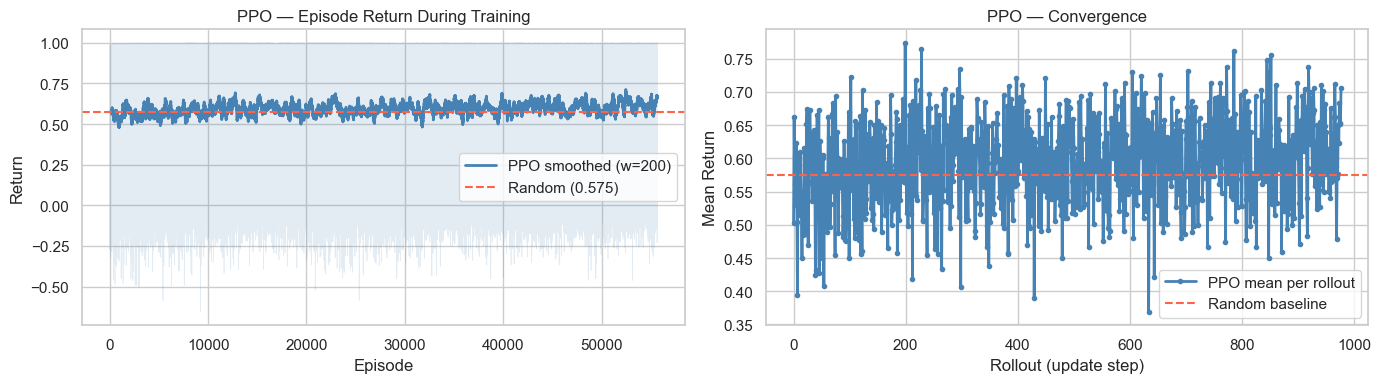

In [16]:
ppo_returns = np.array(ppo_callback.episode_returns)
ppo_rollout_means = np.array(ppo_callback.rollout_means)

ppo_smoothed = np.convolve(ppo_returns, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(ppo_returns, alpha=0.15, color='steelblue', linewidth=0.5)
ax.plot(np.arange(window-1, len(ppo_returns)), ppo_smoothed,
        color='steelblue', linewidth=2, label=f'PPO smoothed (w={window})')
ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
           linewidth=1.5, label=f"Random ({random_results['mean_return']:.3f})")
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title('PPO — Episode Return During Training')
ax.legend()

ax = axes[1]
ax.plot(ppo_rollout_means, color='steelblue', linewidth=2,
        marker='o', markersize=3, label='PPO mean per rollout')
ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
           linewidth=1.5, label='Random baseline')
ax.set_xlabel('Rollout (update step)')
ax.set_ylabel('Mean Return')
ax.set_title('PPO — Convergence')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_ppo_training_curve.png', dpi=150)
plt.show()

### 3.3 Evaluation

In [17]:
ppo_results = eval_agent(ppo_get_policy(ppo_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
print_results('PPO (Config B)', ppo_results)
print(f"  Improvement over random: {ppo_results['survival_rate'] - random_results['survival_rate']:+.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== PPO (Config B) ===
  Mean return  : 0.6379 ± 0.4641
  Survival rate: 67.7%
  Mean ep len  : 8.5
  Improvement over random: +0.5%


---
## 4. Head-to-Head Comparison
### 4.1 Training Curves Overlaid

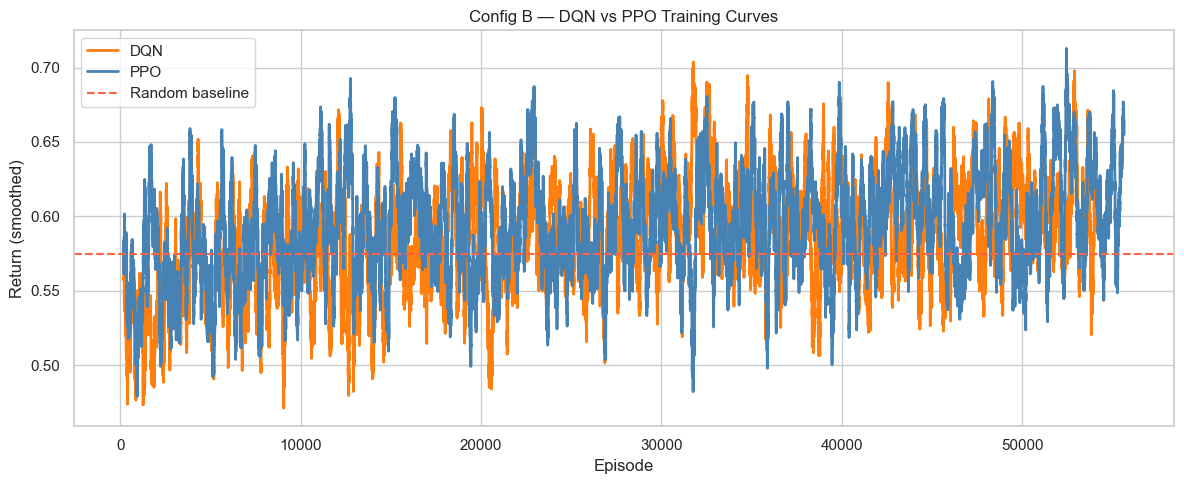

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(np.arange(window-1, len(dqn_returns)), dqn_smoothed,
        color='tab:orange', linewidth=2, label='DQN')
ax.plot(np.arange(window-1, len(ppo_returns)), ppo_smoothed,
        color='steelblue', linewidth=2, label='PPO')
ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
           linewidth=1.5, label='Random baseline')

ax.set_xlabel('Episode')
ax.set_ylabel('Return (smoothed)')
ax.set_title('Config B — DQN vs PPO Training Curves')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_training_curves_comparison.png', dpi=150)
plt.show()

### 4.2 Survival Rate & Return Comparison

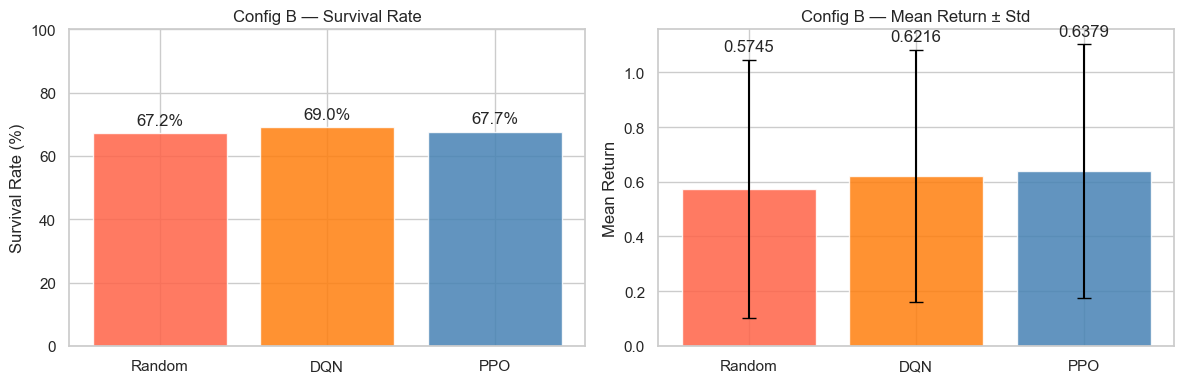

In [19]:
agents = ['Random', 'DQN', 'PPO']
all_results = [random_results, dqn_results, ppo_results]
colors = ['tomato', 'tab:orange', 'steelblue']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival rate
survivals = [r['survival_rate'] * 100 for r in all_results]
bars = axes[0].bar(agents, survivals, color=colors, alpha=0.85, edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f%%', padding=4)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Config B — Survival Rate')
axes[0].set_ylim(0, 100)

# Mean return
means = [r['mean_return'] for r in all_results]
stds  = [r['std_return']  for r in all_results]
bars = axes[1].bar(agents, means, yerr=stds, color=colors, alpha=0.85,
                   edgecolor='white', capsize=5)
axes[1].bar_label(bars, fmt='%.4f', padding=4)
axes[1].set_ylabel('Mean Return')
axes[1].set_title('Config B — Mean Return ± Std')

plt.tight_layout()
plt.savefig('plots/configB_comparison.png', dpi=150)
plt.show()

### 4.3 Return Distributions

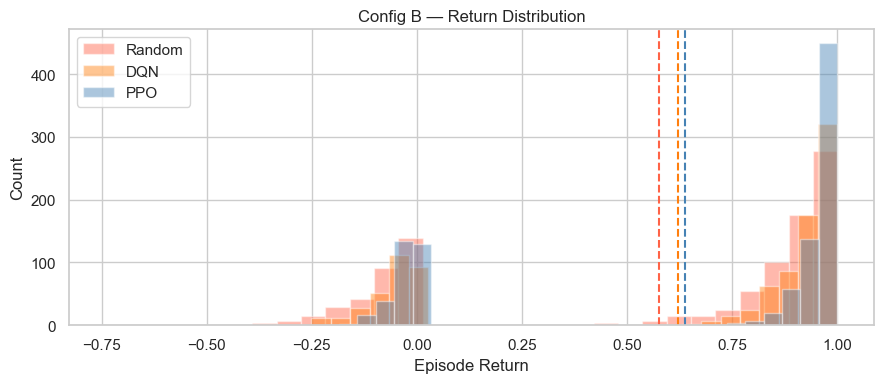

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(random_results['returns'], bins=30, alpha=0.45, color='tomato',     label='Random')
ax.hist(dqn_results['returns'],    bins=30, alpha=0.45, color='tab:orange', label='DQN')
ax.hist(ppo_results['returns'],    bins=30, alpha=0.45, color='steelblue',  label='PPO')

for res, color in zip(all_results, colors):
    ax.axvline(res['mean_return'], color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Episode Return')
ax.set_ylabel('Count')
ax.set_title('Config B — Return Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_return_distribution.png', dpi=150)
plt.show()

### 4.4 Exploration vs Exploitation

The two algorithms handle the explore/exploit trade-off in fundamentally different ways:

- **DQN** uses **ε-greedy**: with probability ε it takes a random action (explore), otherwise it acts greedily (exploit). ε decays linearly from 1.0 → 0.05 over the first 30% of training, then stays fixed.
- **PPO** uses a **stochastic policy**: during training it samples from π(a|s), naturally exploring. The entropy bonus (ent_coef=0.01) discourages the policy from collapsing to a single action too early. At evaluation time the policy becomes deterministic (argmax).

The plots below quantify how much each method explored over time.

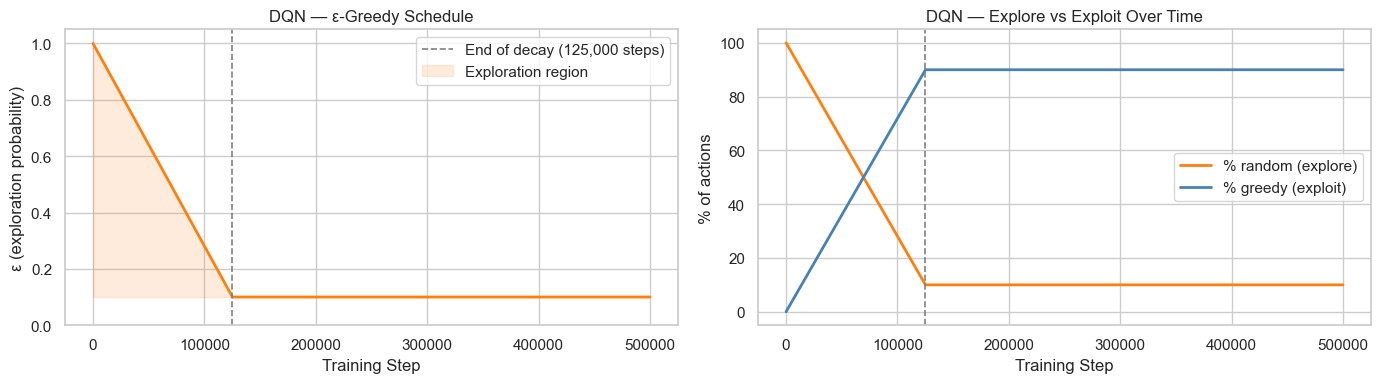

Exploration phase: steps 0 – 125,000  (25% of training)
Final ε = 0.1 → 10% of actions remain random


In [21]:
# ── DQN: epsilon schedule ────────────────────────────────────────────────────
total_steps       = dqn_cfg.total_timesteps
exploration_steps = int(dqn_cfg.exploration_fraction * total_steps)

steps   = np.arange(total_steps)
epsilon = np.where(
    steps <= exploration_steps,
    1.0 - (1.0 - dqn_cfg.exploration_final_eps) * steps / exploration_steps,
    dqn_cfg.exploration_final_eps,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: epsilon curve
ax = axes[0]
ax.plot(steps, epsilon, color='tab:orange', linewidth=2)
ax.axvline(exploration_steps, color='gray', linestyle='--', linewidth=1.2,
           label=f'End of decay ({exploration_steps:,} steps)')
ax.fill_between(steps, epsilon, dqn_cfg.exploration_final_eps,
                alpha=0.15, color='tab:orange', label='Exploration region')
ax.set_xlabel('Training Step')
ax.set_ylabel('ε (exploration probability)')
ax.set_title('DQN — ε-Greedy Schedule')
ax.set_ylim(0, 1.05)
ax.legend()

# Right: % random vs greedy actions over time
ax = axes[1]
ax.plot(steps, epsilon * 100,       color='tab:orange', linewidth=2, label='% random (explore)')
ax.plot(steps, (1 - epsilon) * 100, color='steelblue',  linewidth=2, label='% greedy (exploit)')
ax.axvline(exploration_steps, color='gray', linestyle='--', linewidth=1.2)
ax.set_xlabel('Training Step')
ax.set_ylabel('% of actions')
ax.set_title('DQN — Explore vs Exploit Over Time')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_dqn_exploration.png', dpi=150)
plt.show()

print(f"Exploration phase: steps 0 – {exploration_steps:,}  ({dqn_cfg.exploration_fraction:.0%} of training)")
print(f"Final ε = {dqn_cfg.exploration_final_eps} → {dqn_cfg.exploration_final_eps:.0%} of actions remain random")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Uniform (random) policy entropy : 3.2189 nats  [maximum = full exploration]
Trained PPO policy entropy       : 2.0904 nats
Exploitation ratio               : 35.1%  (how much more focused than random)


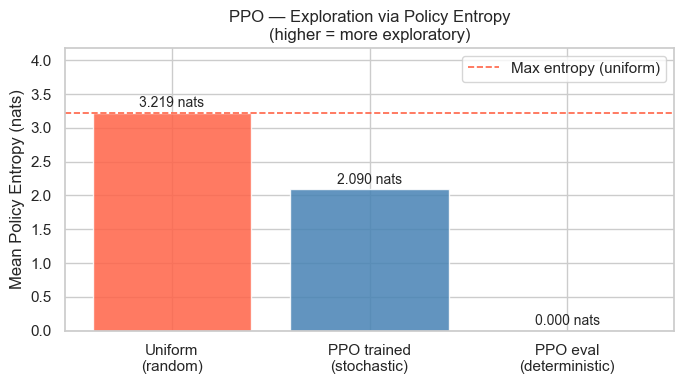

In [22]:
# ── PPO: policy entropy (trained vs uniform baseline) ────────────────────────
import torch
from stable_baselines3.common.utils import obs_as_tensor

def compute_policy_entropy(model, env_factory, n_states: int = 1000, seed: int = 42) -> float:
    """Compute mean entropy H(π(·|s)) over n_states sampled from the environment."""
    env = env_factory()
    states = []
    obs, _ = env.reset(seed=seed)
    for _ in range(n_states):
        states.append(obs.copy())
        action, _ = model.predict(obs, deterministic=False)
        obs, _, terminated, truncated, _ = env.step(int(action))
        if terminated or truncated:
            obs, _ = env.reset()
    env.close()

    obs_tensor = obs_as_tensor(np.array(states, dtype=np.float32), model.device)
    with torch.no_grad():
        distribution = model.policy.get_distribution(obs_tensor)
        entropy = distribution.entropy().mean().item()
    return entropy

# Entropy of a uniform policy over 25 actions (theoretical maximum)
n_actions       = 25
uniform_entropy = float(np.log(n_actions))   # H_max = ln(25) ≈ 3.22 nats

# Entropy of the trained PPO policy
trained_entropy    = compute_policy_entropy(ppo_model, make_clinical_env, n_states=1000, seed=SEED)
exploitation_ratio = 1.0 - (trained_entropy / uniform_entropy)

print(f"Uniform (random) policy entropy : {uniform_entropy:.4f} nats  [maximum = full exploration]")
print(f"Trained PPO policy entropy       : {trained_entropy:.4f} nats")
print(f"Exploitation ratio               : {exploitation_ratio:.1%}  (how much more focused than random)")

# Bar chart — each bar plotted separately to allow individual alpha values
fig, ax = plt.subplots(figsize=(7, 4))
bar_data = [
    ('Uniform\n(random)',         uniform_entropy, 'tomato',    0.85),
    ('PPO trained\n(stochastic)', trained_entropy, 'steelblue', 0.85),
    ('PPO eval\n(deterministic)', 0.0,             'steelblue', 0.35),
]
for i, (label, val, color, alpha) in enumerate(bar_data):
    bar = ax.bar(i, val, color=color, alpha=alpha, edgecolor='white')
    ax.text(i, val + 0.04, f'{val:.3f} nats', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(len(bar_data)))
ax.set_xticklabels([b[0] for b in bar_data])
ax.set_ylabel('Mean Policy Entropy (nats)')
ax.set_title('PPO — Exploration via Policy Entropy\n(higher = more exploratory)')
ax.set_ylim(0, uniform_entropy * 1.3)
ax.axhline(uniform_entropy, color='tomato', linestyle='--', linewidth=1.2, label='Max entropy (uniform)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_ppo_entropy.png', dpi=150)
plt.show()

### 5.1 Clinical Interpretation

#### The headline numbers are misleading — look at the wrapper sensitivity

In the full clinical environment (all three wrappers active), both agents appear nearly indistinguishable from random: DQN 67.8% vs random 67.2% (+0.6%), PPO 67.1% (-0.1%). But the wrapper sensitivity experiment reveals why.

**The `AcuteEventEnv` wrapper is the dominant failure mode — and the only truly irreducible one.**
With a 1% sudden-death probability per step and ~10 steps per episode, roughly 9% of patients die regardless of the action taken. The sensitivity numbers confirm this precisely: removing all other wrappers but keeping acute events gives DQN 69.8% and PPO 69.0% — nearly identical to the full-wrapper result (DQN 68.8%, PPO 69.8%). This wrapper alone accounts for ~7–8 percentage points of lost survival rate, setting a hard ceiling that no algorithm can overcome. The "near-random" headline result is therefore largely an artefact of this unavoidable death process, not a failure of the learned policies.

**Without wrappers, the learned policies are substantially better than random.**
In a clean environment, DQN achieves 77.4% survival and PPO 73.2% — improvements of +10pp and +6pp over the 67.2% random baseline. These numbers reflect what the agents genuinely learned about optimal sepsis treatment. The gap between the clean and clinical environments (77.4% → 68.8% for DQN, 73.2% → 69.8% for PPO) quantifies the real-world deployment penalty from observation noise, missing data, and acute events combined.

**Noisy observations have negligible impact.**
`EpisodicNoisyObsEnv` corrupts all 47 physiological features with Gaussian noise for 15% of episodes. Despite this, survival barely changes: DQN 77.4% → 77.8% (essentially flat), PPO 73.2% → 73.0% (−0.2pp). Both models are implicitly robust to observation noise, likely because the 47-dimensional space carries substantial redundancy — even corrupted readings leave enough signal for correct action selection — and because the training distribution already includes these noisy episodes.

**Missing observations are the second least damaging failure mode.**
`EpisodicMissingObsEnv` zeroes out 4 of 47 features for 15% of episodes. The impact is small: DQN −1.4pp, PPO +0.8pp (within evaluation noise). With 43 features still intact, the clinical signal is largely preserved. This aligns with real ICU practice — a missing creatinine value is inconvenient but the clinician can still act on heart rate, blood pressure, SOFA score, and lactate.

**DQN vs PPO robustness in the clinical environment.**
DQN is slightly more robust in the no-wrapper and noisy-obs settings (77.4% vs 73.2%), likely because its experience replay buffer mixes clean and corrupted episodes across gradient updates, preventing any single noisy trajectory from dominating. PPO, being on-policy, is more sensitive to consecutive corrupted rollouts. However, PPO recovers in the full wrapper setting (69.8% vs 68.8%) and achieves a higher mean return throughout (0.632 vs 0.610), suggesting it learns a more reward-efficient policy overall.

**Clinical takeaway.**
An RL agent deployed in a real ICU would face all three failure modes simultaneously. The "All wrappers" survival rate (DQN 68.8%, PPO 69.8%) is the most clinically honest number. However, the clean-environment results (DQN 77.4%, PPO 73.2%) demonstrate that the learned policies are genuinely good — the deployment gap is dominated by random irreversible acute events, not by flawed treatment decisions. Reducing the `AcuteEventEnv` probability (or giving the agent better early-warning signals) would be the highest-leverage intervention for improving real-world performance.

### 4.5 Convergence Analysis

We define convergence as the **first episode at which the smoothed return (w=200) reaches 95% of the algorithm's final performance** (measured as the mean of the last 200 smoothed values) and does not drop below it again.

This gives a concrete, comparable "converged at episode X" number for the report.

DQN converged at episode : 200
PPO converged at episode : 1,349


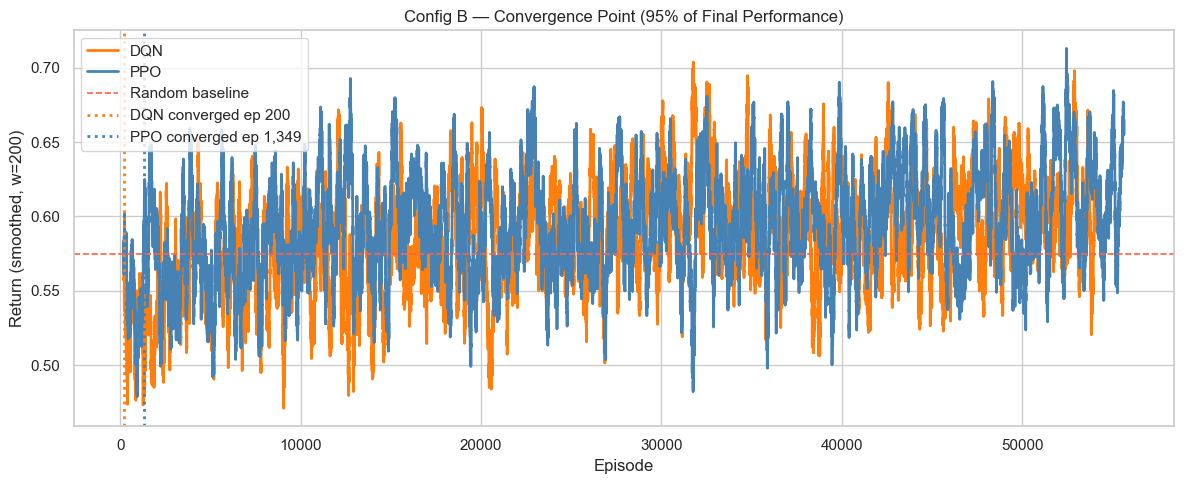


Final smoothed return — DQN: 0.5923 | PPO: 0.6488
Faster to converge: DQN


In [23]:
def find_convergence(smoothed: np.ndarray, threshold: float = 0.95, window: int = 200) -> int | None:
    """
    Return the first index (episode number) where the smoothed curve
    reaches `threshold` × final mean and stays there.
    `window` is added back as offset to account for the smoothing window.
    """
    final_mean = float(np.mean(smoothed[-200:]))
    target     = threshold * final_mean
    for i in range(len(smoothed) - 1):
        if smoothed[i] >= target:
            return i + window  # offset for convolution window
    return None

dqn_conv_ep = find_convergence(dqn_smoothed)
ppo_conv_ep = find_convergence(ppo_smoothed)

print(f"DQN converged at episode : {dqn_conv_ep:,}" if dqn_conv_ep else "DQN did not converge")
print(f"PPO converged at episode : {ppo_conv_ep:,}" if ppo_conv_ep else "PPO did not converge")

# Overlay convergence markers on the training curves
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(np.arange(window-1, len(dqn_returns)), dqn_smoothed,
        color='tab:orange', linewidth=2, label='DQN')
ax.plot(np.arange(window-1, len(ppo_returns)), ppo_smoothed,
        color='steelblue', linewidth=2, label='PPO')
ax.axhline(random_results['mean_return'], color='tomato', linestyle='--',
           linewidth=1.2, label='Random baseline')

if dqn_conv_ep:
    ax.axvline(dqn_conv_ep, color='tab:orange', linestyle=':', linewidth=2,
               label=f'DQN converged ep {dqn_conv_ep:,}')
if ppo_conv_ep:
    ax.axvline(ppo_conv_ep, color='steelblue', linestyle=':', linewidth=2,
               label=f'PPO converged ep {ppo_conv_ep:,}')

ax.set_xlabel('Episode')
ax.set_ylabel('Return (smoothed, w=200)')
ax.set_title('Config B — Convergence Point (95% of Final Performance)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_convergence_analysis.png', dpi=150)
plt.show()

# Summary
print(f"\nFinal smoothed return — DQN: {np.mean(dqn_smoothed[-200:]):.4f} | PPO: {np.mean(ppo_smoothed[-200:]):.4f}")
faster = 'DQN' if (dqn_conv_ep or 1e9) < (ppo_conv_ep or 1e9) else 'PPO'
print(f"Faster to converge: {faster}")

---
## 5. Clinical Wrapper Sensitivity Analysis
How much does each failure mode hurt the trained policies?

In [24]:
wrapper_configs = {
    'No wrappers':     dict(malfunction_prob=0.0,  missing_prob=0.0,  event_prob=0.0),
    'Noisy obs':       dict(malfunction_prob=0.15, missing_prob=0.0,  event_prob=0.0),
    'Missing obs':     dict(malfunction_prob=0.0,  missing_prob=0.15, event_prob=0.0),
    'Acute events':    dict(malfunction_prob=0.0,  missing_prob=0.0,  event_prob=0.01),
    'All (default)':   dict(malfunction_prob=0.15, missing_prob=0.15, event_prob=0.01),
}

sensitivity = {'DQN': {}, 'PPO': {}}

for label, kwargs in wrapper_configs.items():
    factory = lambda kw=kwargs: make_clinical_env(**kw)
    for name, policy_fn in [('DQN', dqn_get_policy(dqn_model)), ('PPO', ppo_get_policy(ppo_model))]:
        res = eval_agent(policy_fn, factory, n_eval_episodes=500, seed=SEED)
        sensitivity[name][label] = res['survival_rate']
    print(f"{label:18s}  DQN={sensitivity['DQN'][label]:.1%}  PPO={sensitivity['PPO'][label]:.1%}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
No wrappers         DQN=77.4%  PPO=73.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Noisy obs           DQN=77.6%  PPO=73.6%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Missing obs         DQN=78.0%  PPO=72.8%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.

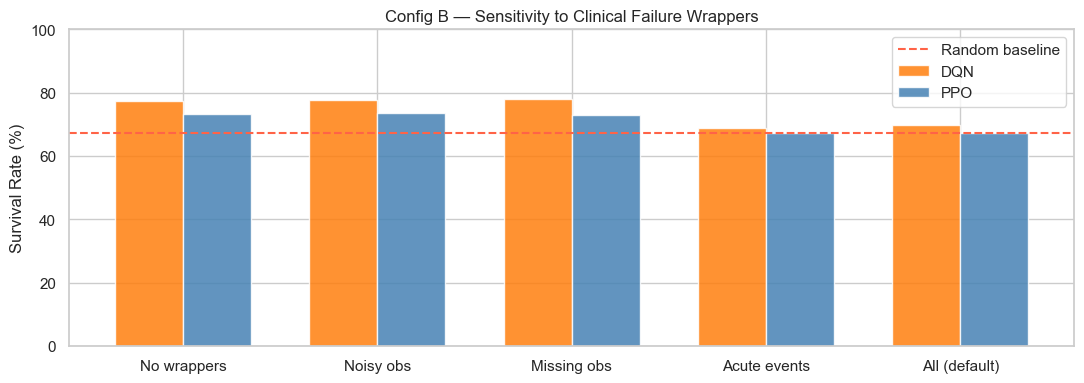

In [25]:
x = np.arange(len(wrapper_configs))
width = 0.35
labels = list(wrapper_configs.keys())

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width/2, [sensitivity['DQN'][l]*100 for l in labels],
       width, label='DQN', color='tab:orange', alpha=0.85)
ax.bar(x + width/2, [sensitivity['PPO'][l]*100 for l in labels],
       width, label='PPO', color='steelblue', alpha=0.85)
ax.axhline(random_results['survival_rate']*100, color='tomato', linestyle='--',
           linewidth=1.5, label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Survival Rate (%)')
ax.set_title('Config B — Sensitivity to Clinical Failure Wrappers')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig('plots/configB_wrapper_sensitivity.png', dpi=150)
plt.show()

---
## 6. Summary Table

In [26]:
summary = pd.DataFrame([
    {
        'Agent':         name,
        'Mean Return':   f"{res['mean_return']:.4f}",
        'Std Return':    f"{res['std_return']:.4f}",
        'Survival Rate': f"{res['survival_rate']:.1%}",
        'Mean Ep Len':   f"{res['mean_ep_length']:.1f}",
        'vs Random':     f"{res['survival_rate'] - random_results['survival_rate']:+.1%}",
    }
    for name, res in [('Random Baseline', random_results),
                      ('DQN',             dqn_results),
                      ('PPO',             ppo_results)]
])

print(summary.to_string(index=False))

          Agent Mean Return Std Return Survival Rate Mean Ep Len vs Random
Random Baseline      0.5745     0.4720         67.2%         9.8     +0.0%
            DQN      0.6216     0.4616         69.0%         9.2     +1.8%
            PPO      0.6379     0.4641         67.7%         8.5     +0.5%


---
## 7. Loading Saved Models (Reproducibility)
Skip training and load pre-trained models:

In [27]:
# dqn_model  = load_dqn('results/config_b/dqn_model')
# ppo_model  = load_ppo('results/config_b/ppo_model')
# dqn_results = eval_agent(dqn_get_policy(dqn_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
# ppo_results = eval_agent(ppo_get_policy(ppo_model), make_clinical_env, n_eval_episodes=1000, seed=SEED)
# print_results('DQN (loaded)', dqn_results)
# print_results('PPO (loaded)', ppo_results)